In [19]:
from netCDF4 import Dataset
import numpy as np

from RasterClipperFunctions import clipImage
import raster

from matplotlib import pyplot as plt

In [20]:
ds = Dataset('/home/jovyan/shared-public/NSIDC-0793/NSIDC-0793_19720915-20220215_V01.0.nc', 'r')
x = ds['x'][:]
y = ds['y'][:]
ds.close()

x_resolution = (x[1]-x[0])
y_resolution = (y[1]-y[0])

gt = [x[0]-x_resolution/2, x_resolution, 0, y[0]-y_resolution/2, 0, y_resolution]


In [21]:
mask = np.nan * np.ones((len(y), len(x)))

for i in range(1,8):
    fname = '/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_{:d}.txt'.format(i)
    print(fname)
    x_basin = []
    y_basin = []

    with open(fname, 'r') as file:
        for line in file:
            if not line.startswith('#'):
                # Process the data lines
                data = line.strip().split(',')  # Example: splitting by comma
                x_basin.append(float(data[0]))
                y_basin.append(float(data[1]))
    x_basin = np.array(x_basin)
    y_basin = np.array(y_basin)

    mask_clipped = clipImage(np.ones((len(y), len(x))), x_basin, y_basin, gt)
    mask = np.where(mask_clipped == 1, i, mask)

mask_clipped = x_basin = y_basin = None

/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_1.txt
/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_2.txt
/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_3.txt
/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_4.txt
/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_5.txt
/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_6.txt
/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_7.txt


In [22]:
import sys
def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))

                          mask:  2.3 GiB
                       x_basin:  1.3 KiB
                       y_basin:  1.3 KiB
                            _i:  791.0 B
                          _i21:  791.0 B
                          _i22:  595.0 B
                       Dataset:  424.0 B
                           _ii:  324.0 B
                          _i20:  324.0 B
                            ds:  256.0 B


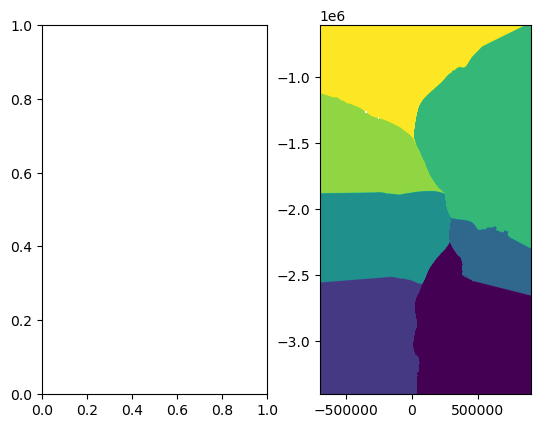

In [23]:
fig, ax = plt.subplots(1,2)
#ax[0].plot(x_basin, y_basin)
ax[1].imshow(mask, extent=raster.gt2extent(mask, gt))


In [59]:
%%time

ds = Dataset('/home/jovyan/shared-public/NSIDC-0793/NSIDC-0793_19720915-20220215_V01.0.nc', 'r')
#x = ds['x'][:]
#y = ds['y'][:]

basin_extent = np.nan * np.ones((7, ds['ice_mask'].shape[0]))
for itime in tqdm(range(ds['ice_mask'].shape[0])):
    ice_mask = ds['ice_mask'][itime,:,:]
    for ibasin, basin_num in enumerate(range(1,8)):
        basin_extent[ibasin, itime] = np.sum((mask == basin_num) & (ice_mask == 1)) * x_resolution * -y_resolution

ds.close()

100%|██████████| 594/594 [2:37:56<00:00, 15.95s/it]  

CPU times: user 2h 11min 47s, sys: 26min 7s, total: 2h 37min 55s
Wall time: 2h 37min 56s


In [61]:
import pickle

data = {'basin_extent': basin_extent}

with open('basin_extent.pickle', 'wb') as file:
    pickle.dump(data, file)

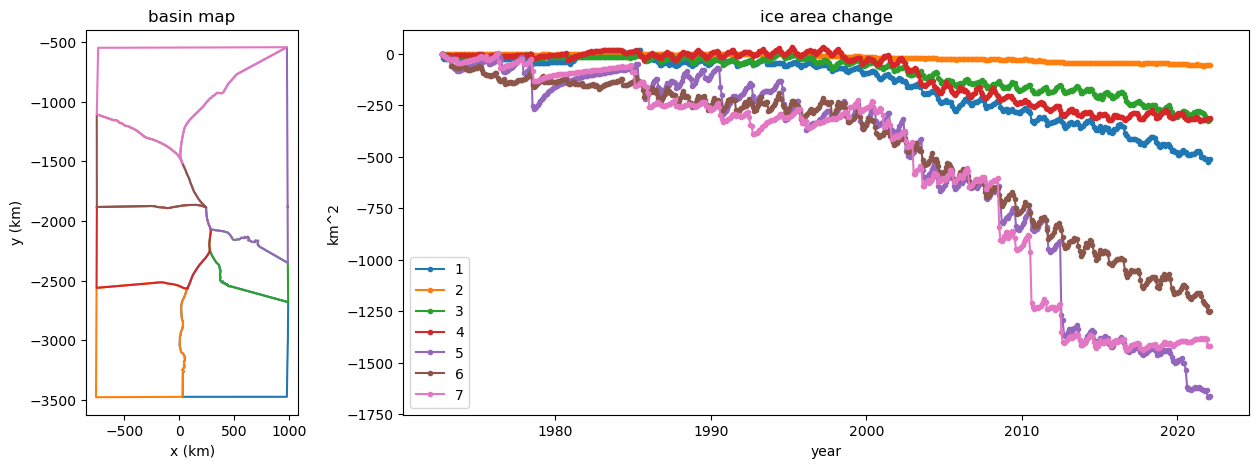

In [92]:
import xarray as xr

ds = xr.open_dataset('/home/jovyan/shared-public/NSIDC-0793/NSIDC-0793_19720915-20220215_V01.0.nc')
time = ds.time
ds.close()

fig, ax = plt.subplots(1,2,figsize=(15,5),gridspec_kw={'width_ratios': [1,4]})

for ibasin, basin_num in enumerate(range(1,8)):
    # Plot basins
    fname = '/home/jovyan/shared-public/ISMIP7/BasinsAndSectors/ice_sector_{:d}.txt'.format(basin_num)
    x_basin = []
    y_basin = []
    with open(fname, 'r') as file:
        for line in file:
            if not line.startswith('#'):
                # Process the data lines
                data = line.strip().split(',')  # Example: splitting by comma
                x_basin.append(float(data[0]))
                y_basin.append(float(data[1]))
    x_basin = np.array(x_basin)
    y_basin = np.array(y_basin)
    
    ax[0].plot(x_basin/1e3, y_basin/1e3, label=basin_num)
    
    # Plot ice area change
    ax[1].plot(time, (basin_extent[ibasin,:]-basin_extent[ibasin,0])/1e6, '.-', label=basin_num)

ax[0].set_title('basin map')
ax[0].set_xlabel('x (km)')
ax[0].set_ylabel('y (km)')

ax[1].set_title('ice area change')
ax[1].set_xlabel('year')
ax[1].set_ylabel('km^2')
ax[1].legend()
